In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import norm



In [23]:
df = pd.read_csv('house_prices - house_prices.csv')

In [4]:
df.head()


,square_footage,price_lakhs
0,1998,98
1,1744,122
2,2059,40
3,2409,89
4,1706,58


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   square_footage  504 non-null    int64
 1   price_lakhs     504 non-null    int64
dtypes: int64(2)
memory usage: 8.0 KB


In [6]:
df.describe()

,square_footage,price_lakhs
count,504.000000,504.000000
mean,1812.924603,76.111111
std,482.815297,27.797613
min,503.000000,7.000000
25%,1518.250000,59.750000
50%,1805.000000,75.000000
75%,2058.250000,91.000000
max,8000.000000,300.000000


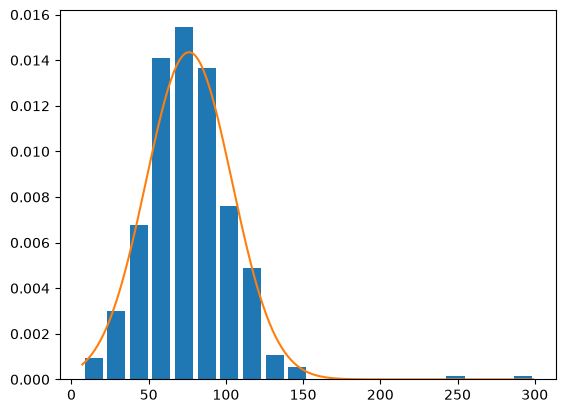

In [9]:
matplotlib.rcParams['figure.figsize']

plt.hist(df['price_lakhs'], bins=20, rwidth=0.8, density=True)
rng = np.arange(df.price_lakhs.min(), df.price_lakhs.max(), 1)
plt.plot(rng, norm.pdf(rng, df.price_lakhs.mean(), df.price_lakhs.std()))
plt.show()

In [24]:
mean_price = df.price_lakhs.mean()
std_price = df.price_lakhs.std()
print(mean_price, std_price)

76.11111111111111 27.797613417080303


In [11]:
upper_limit = mean_price + 3*std_price
lower_limit = mean_price - 3*std_price
print(upper_limit, lower_limit)

159.50395136235204 -7.281729140129798


In [13]:
outliers = df[(df['price_lakhs'] < lower_limit) | (df['price_lakhs'] > upper_limit)]
outliers

,square_footage,price_lakhs
500,600,250
503,2500,300


In [17]:
df_clean_std = df[(df['price_lakhs'] > lower_limit) & (df['price_lakhs'] < upper_limit)]
print(df_clean_std.shape[0],
df.shape[0])

502 504


Text(0.5, 1.0, 'Cleaned data')

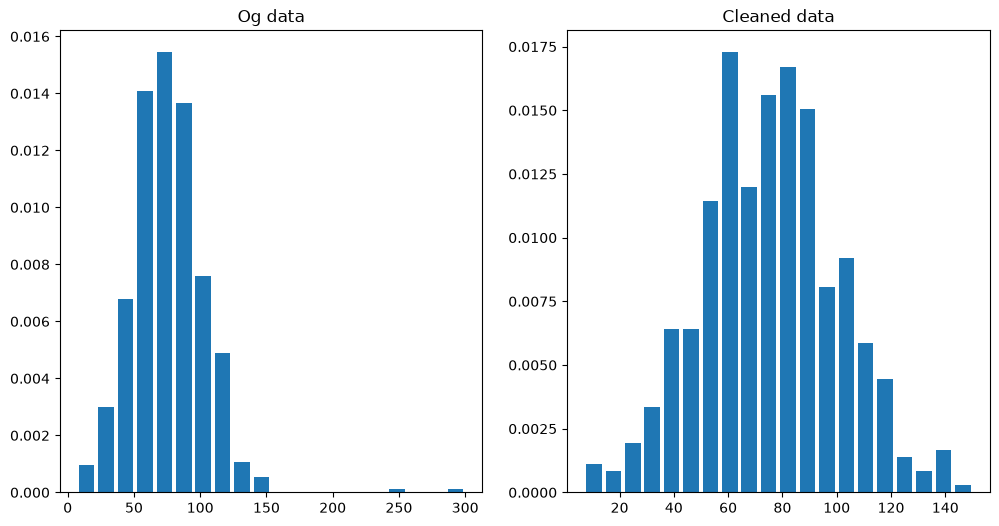

In [25]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df['price_lakhs'], bins=20, rwidth=0.8, density=True)
plt.title("Og data")

plt.subplot(1,2,2)
plt.hist(df_clean_std['price_lakhs'], bins=20, rwidth=0.8, density=True)
plt.title("Cleaned data")

method 4: Outlier detection and removal using z score

In [20]:
df['z_score'] = (df.price_lakhs- mean_price)/std_price
df.head()

,square_footage,price_lakhs,z_score
0,1998,98,0.787438
1,1744,122,1.650821
2,2059,40,-1.299072
3,2409,89,0.463669
4,1706,58,-0.651535


In [21]:
outliers2 = df[(df['z_score'] < -3) | (df['z_score'] > 3)]
outliers2

,square_footage,price_lakhs,z_score
500,600,250,6.255533
503,2500,300,8.054249


In [22]:
df_no_outlier = df[(df['z_score'] >-3) & (df['z_score'] < 3)]
df_no_outlier.head()

,square_footage,price_lakhs,z_score
0,1998,98,0.787438
1,1744,122,1.650821
2,2059,40,-1.299072
3,2409,89,0.463669
4,1706,58,-0.651535
